# MiloDE on in vitro HE multiome

# To do:
- filter by CDR (not just minimum expression) <--- most important
- Use embryo as covariate instead of sample <--- 2nd most important
- Optimize Nhoods
- Downstream analysis (GO??)

In [1]:
suppressPackageStartupMessages({
    library(miloDE)
    library(scuttle)
    suppressMessages(library(miloR))
    suppressMessages(library(uwot))
    library(scran)
    suppressMessages(library(dplyr))
    library(reshape2)
    library(scWGCNA)
    suppressMessages(library(Seurat))
    library(ggplot2)
    library(viridis)
    library(ggpubr)
    library(BiocParallel)
    library(data.table)
})
ncores = 16
mcparam = MulticoreParam(workers = ncores)
register(mcparam)

In [2]:
main = "/rds/project/rds-SDzz0CATGms/users/bt392/01_Eomes_RNA/"
source(paste0(main, "mapping_functions.R"))
args = list() 
args$outdir = file.path(main, '11_miloDE/')
dir.create(args$outdir, recursive=TRUE, showWarnings =FALSE)


Attaching package: ‘cowplot’


The following object is masked from ‘package:ggpubr’:

    get_legend


Warning message:
“The `size` argument of `element_rect()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.”


In [3]:

load_data(remove_doublets = TRUE, remove_stripped = TRUE)
mapping_dir = paste0(main, '07_atlas_mapping/')
meta = read.csv(paste0(mapping_dir, 'meta_complete.csv'))

colData(sce) <- meta %>% tibble::column_to_rownames("cell") %>% DataFrame

pca = read.csv(paste0(main, '06_batch_correct/PCA_corrected.csv'))

rownames(pca) = pca[,1]
pca = pca[,-1]

umap_mapped = colData(sce)[,c('umapX.mapped', 'umapY.mapped')]
reducedDims(sce) <- list(pca.corrected=pca, umap_mapped=umap_mapped)

reducedDim(sce, "pca.corrected") = as.matrix(reducedDim(sce, "pca.corrected"))

Loading required package: scater


Attaching package: ‘scater’


The following object is masked from ‘package:limma’:

    plotMDS




In [4]:
genenames = fread("/rds/project/rds-SDzz0CATGms/users/bt392/gene_names.csv") %>% 
            setnames(c('ensembl_gene_id','external_gene_name'), c('gene', 'gene_name'))
genenames = genenames[genenames$gene %in% rownames(sce)]
genenames = merge(genenames, as.data.frame(rownames(sce)), by.x='gene', by.y='rownames(sce)', all.y=TRUE)
genenames$gene_name[genenames$gene_name==''] = NA
genenames[is.na(genenames$gene_name),] = genenames$gene[is.na(genenames$gene_name)]
genenames = genenames[order(match(genenames$gene, rownames(sce)))]
rownames(sce) = genenames$gene_name

In [ ]:
# Seurat for Luke
seurat = CreateSeuratObject(counts = sce@assays@data$counts)
seurat@assays$RNA@data = sce@assays@data$logcounts
seurat@meta.data = as.data.frame(colData(sce))

# save seurat
saveRDS(seurat, file.path(main, 'seurat.rds'))

In [5]:
EmbryoCelltypeColours = c(
"Epiblast" = "#635547",
  "Primitive_Streak" = "#DABE99",
  "Caudal_epiblast" = "#9e6762",
  "PGC" = "#FACB12",
  "Anterior_Primitive_Streak" = "#c19f70",
  "Notochord" = "#0F4A9C",
  "Def._endoderm" = "#F397C0",
  "Gut" = "#EF5A9D",
  "Nascent_mesoderm" = "#C594BF",
  "Mixed_mesoderm" = "#DFCDE4",
  "Intermediate_mesoderm" = "#139992",
  "Caudal_Mesoderm" = "#3F84AA",
  "Paraxial_mesoderm" = "#8DB5CE",
  "Somitic_mesoderm" = "#005579",
  "Pharyngeal_mesoderm" = "#C9EBFB",
  "Cardiomyocytes" = "#B51D8D",
  "Allantois" = "#532C8A",
  "ExE_mesoderm" = "#8870ad",
  "Mesenchyme" = "#cc7818",
  "Haematoendothelial_progenitors" = "#FBBE92",
  "Endothelium" = "#ff891c",
  "Blood_progenitors" = "#c9a997",
  "Blood_progenitors_1" = "#f9decf",
  "Blood_progenitors_2" = "#c9a997",
  "Erythroid" = "#EF4E22",
  "Erythroid1" = "#C72228",
  "Erythroid2" = "#f79083",
  "Erythroid3" = "#EF4E22",
  "NMP" = "#8EC792",
  "Neurectoderm" = "#65A83E",
  "Rostral_neurectoderm" = "#65A83E",
  "Caudal_neurectoderm" = "#354E23",
  "Neural_crest" = "#C3C388",
  "Forebrain_Midbrain_Hindbrain" = "#647a4f",
  "Spinal_cord" = "#CDE088",
  "Surface_ectoderm" = "#f7f79e",
  "Visceral_endoderm" = "#F6BFCB",
  "ExE_endoderm" = "#7F6874",
  "ExE_ectoderm" = "#989898",
  "Parietal_endoderm" = "#1A1A1A"
)


In [6]:
reducedDims(sce) <- list(pca.corrected=pca, umap=umap_mapped)

In [7]:
sce$celltype.mapped = gsub(' ', '_', gsub('-', '_', gsub('/', '_', sce$celltype.mapped)))

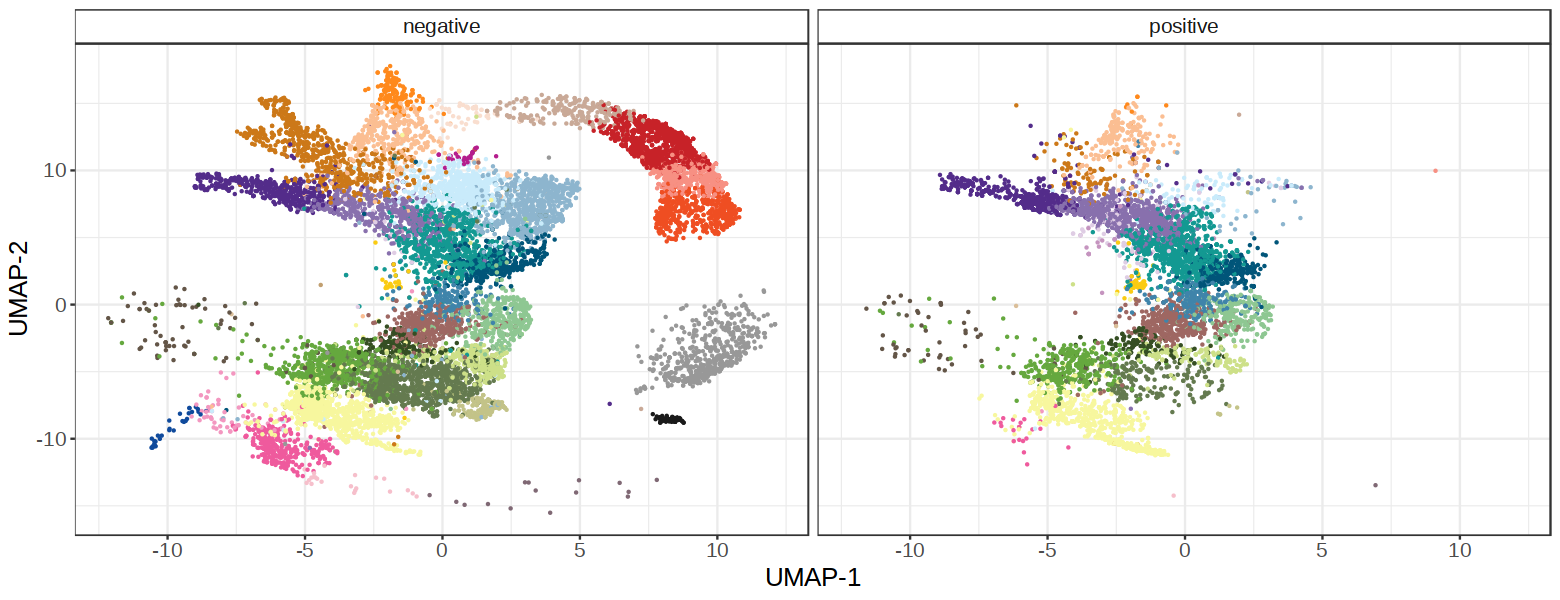

In [8]:
options(repr.plot.height=5, repr.plot.width=13)
# plot UMAPs, colored by cell types
umaps = cbind(as.data.frame(colData(sce)))

p = ggplot(umaps , aes(x = umapX.mapped, y = umapY.mapped , col = celltype.mapped)) +
  geom_point(size=0.2) + 
  scale_color_manual(values=EmbryoCelltypeColours, name='') +
  facet_wrap(~tdTom) +
  theme_bw() + 
  theme(legend.position='none',
       strip.background=element_rect(fill=NA),
       text=element_text(size=15)) + 
  labs(x = "UMAP-1", y = "UMAP-2")
p

In [9]:
sce = sce[!rownames(sce) %in% rownames(sce)[duplicated(rownames(sce))],]

In [10]:
sce

class: SingleCellExperiment 
dim: 29434 27776 
metadata(0):
assays(2): counts logcounts
rownames(29434): Xkr4 Gm1992 ... ENSMUSG00000095742 tomato-td
rowData names(0):
colnames(27776): cell_1 cell_2 ... cell_30169 cell_30171
colData names(21): barcode stage ... umapX.mapped umapY.mapped
reducedDimNames(2): pca.corrected umap
mainExpName: NULL
altExpNames(0):

Running for next k values:
10, 15, 20, 25, 30, 35, 40



100% covered by 394 sets.


Finished for k = 10



100% covered by 237 sets.


Finished for k = 15



...

Finished for k = 30



100% covered by 93 sets.


Finished for k = 35



100% covered by 82 sets.


Finished for k = 40

Finished the estimation of neighbourhood sizes ~ k dependancy (order = 2).



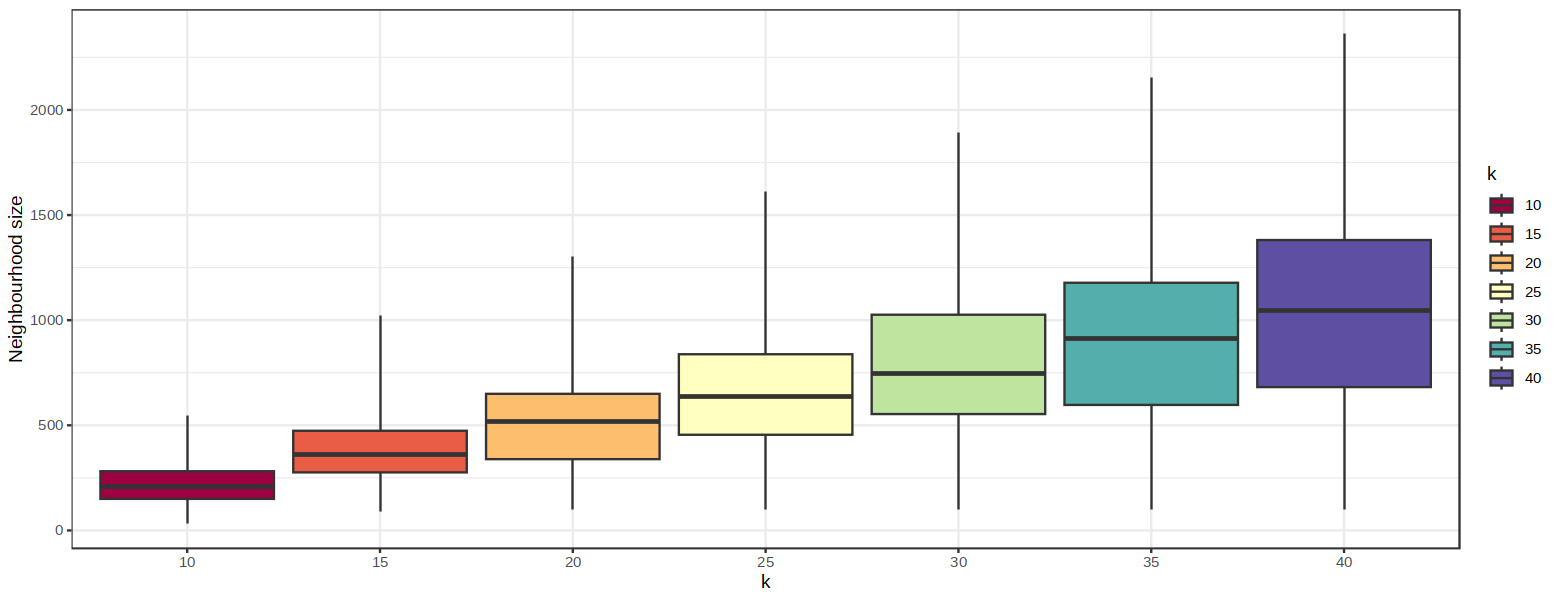

In [19]:
stat_k = estimate_neighbourhood_sizes(sce, k_grid = seq(10,40,5) , 
                                      order = 2, prop = 0.2 , filtering = TRUE,
                                      reducedDim_name = "pca.corrected" , plot_stat = TRUE)

In [20]:
knitr::kable(stat_k , caption = "Neighbourhood size distribution ~ k")



Table: Neighbourhood size distribution ~ k

|k  | min|    q25|    med|     q75|  max|
|:--|---:|------:|------:|-------:|----:|
|10 |  31| 150.00|  208.5|  281.50|  545|
|15 |  92| 276.00|  363.0|  474.00| 1022|
|20 |  99| 339.00|  520.0|  649.75| 1305|
|25 |  99| 455.00|  639.0|  838.00| 1610|
|30 |  99| 553.50|  745.0| 1026.00| 1892|
|35 |  99| 597.00|  913.0| 1178.00| 2153|
|40 |  99| 681.75| 1046.0| 1381.25| 2363|

In [11]:
set.seed(32)
# What does order mean here?
sce_milo = assign_neighbourhoods(sce , k = 15, prop = 0.1, order = 2, 
                                 filtering = TRUE , reducedDim_name = "pca.corrected" , verbose = F)
#> 100% covered by 42 sets.

100% covered by 255 sets.


Converting celltype.mapped to factor...

Warning message in plot_milo_by_single_metric(sce_milo, nhood_stat_ct, colour_by = "celltype.mapped", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


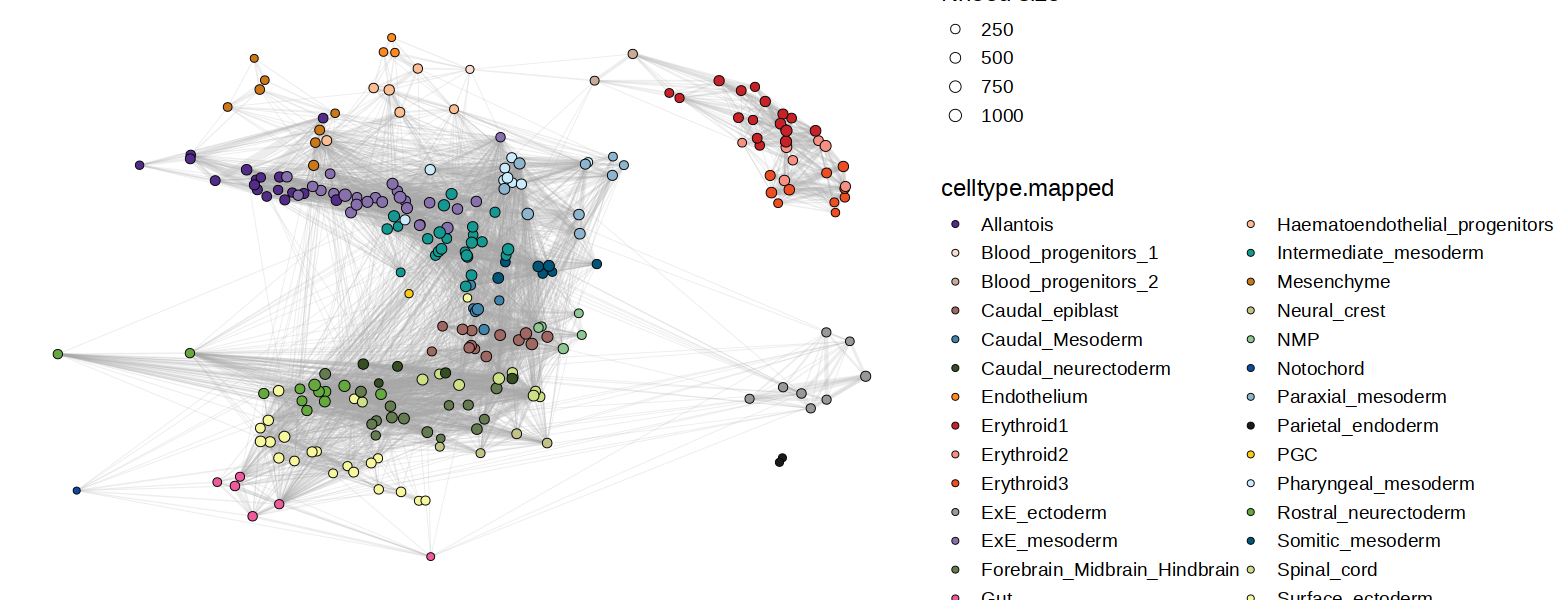

In [12]:
nhoods_sce = nhoods(sce_milo)
# assign cell types for nhoods 
nhood_stat_ct = data.frame(Nhood = 1:ncol(nhoods_sce) , Nhood_center = colnames(nhoods_sce))
nhood_stat_ct = miloR::annotateNhoods(sce_milo , nhood_stat_ct , coldata_col = "celltype.mapped")
#> Converting seurat_clusters to factor...
p = plot_milo_by_single_metric(sce_milo, nhood_stat_ct, colour_by = "celltype.mapped" , 
                                      layout = "umap" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_manual(values = EmbryoCelltypeColours , name = "celltype.mapped")
p

Converting celltype.mapped to factor...

Warning message in plot_milo_by_single_metric(sce_milo, nhood_stat_ct, colour_by = "celltype.mapped", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


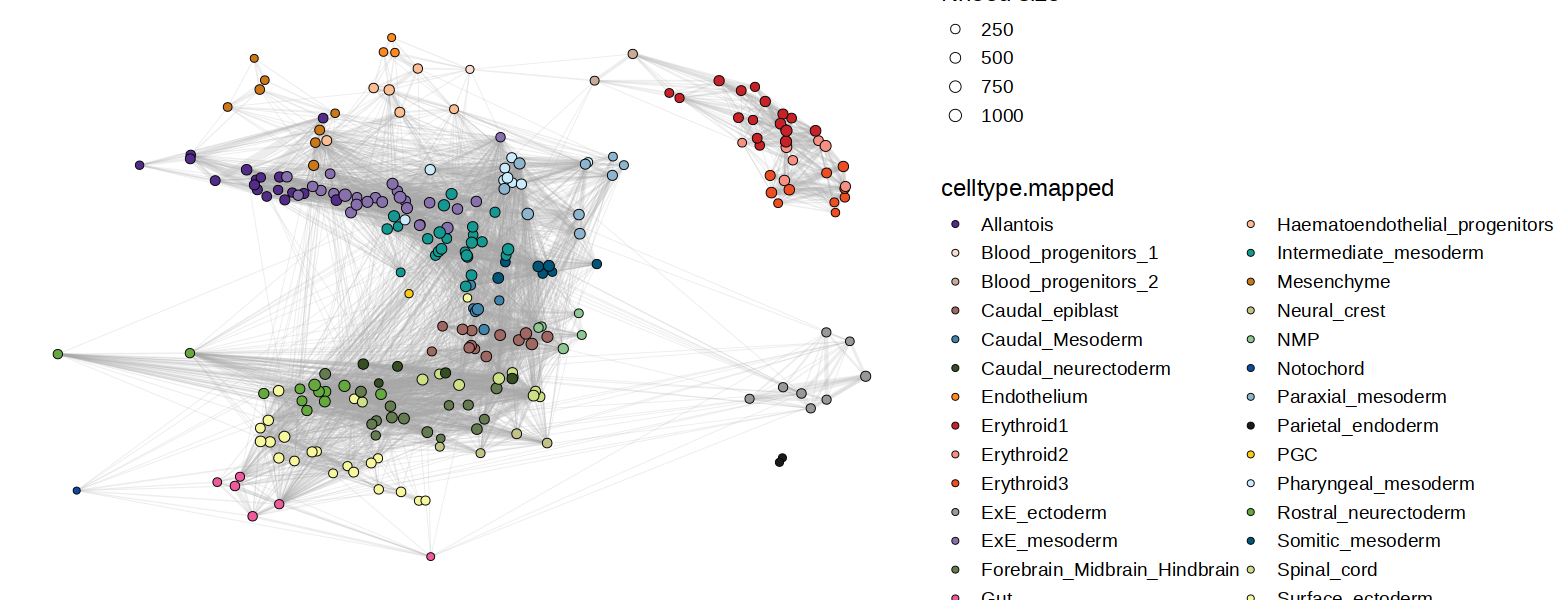

In [13]:
nhoods_sce = nhoods(sce_milo)
# assign cell types for nhoods 
nhood_stat_ct = data.frame(Nhood = 1:ncol(nhoods_sce) , Nhood_center = colnames(nhoods_sce))
nhood_stat_ct = miloR::annotateNhoods(sce_milo , nhood_stat_ct , coldata_col = "celltype.mapped")
#> Converting seurat_clusters to factor...
p = plot_milo_by_single_metric(sce_milo, nhood_stat_ct, colour_by = "celltype.mapped" , 
                                      layout = "umap" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_manual(values = EmbryoCelltypeColours , name = "celltype.mapped")
p

In [14]:
unique(sce_milo$sample)

[1] 3 8 4 5 1 6 2 7

In [15]:
ncores = 16
mcparam = MulticoreParam(workers = ncores)
register(mcparam)

In [16]:
stat_auc = suppressWarnings(calc_AUC_per_neighbourhood(sce_milo , sample_id = "sample" , condition_id = "tdTom", min_n_cells_per_sample = 20, BPPARAM = mcparam))

p = plot_milo_by_single_metric(sce_milo, stat_auc, colour_by = "auc" , 
                                      layout = "umap" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "AUC")

Warning message in plot_milo_by_single_metric(sce_milo, stat_auc, colour_by = "auc", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


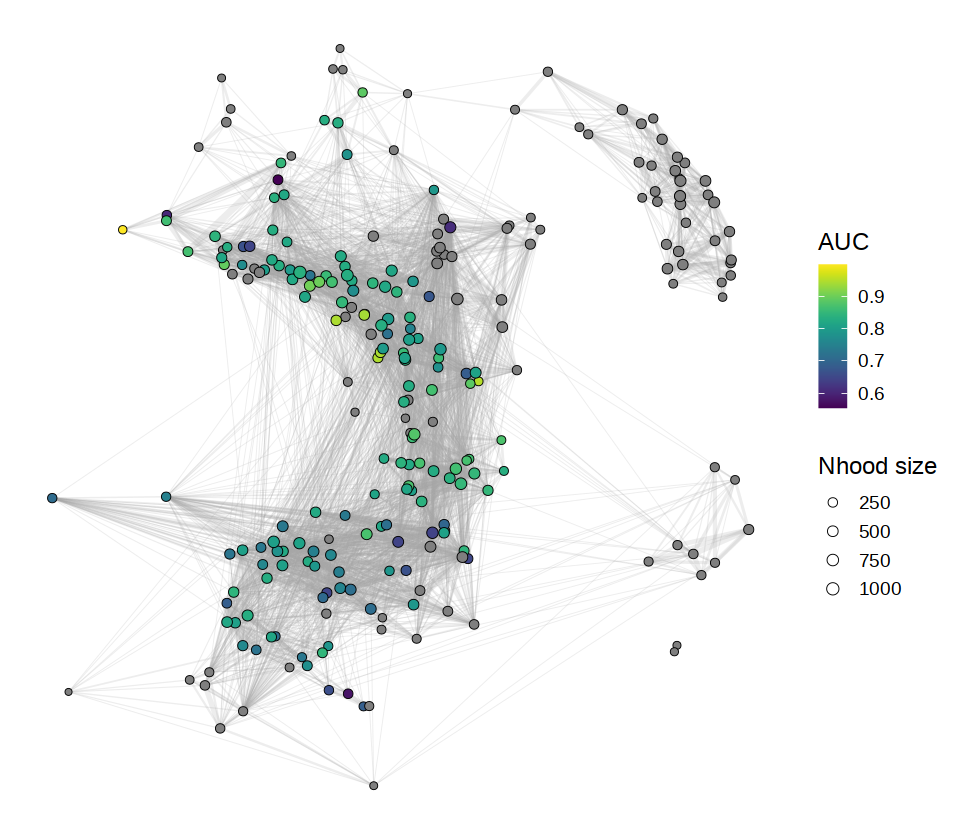

In [17]:
options(repr.plot.height=7, repr.plot.width=8)
p

DE testing is done.
146 neighbourhoods (out of 146) were tested.

Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


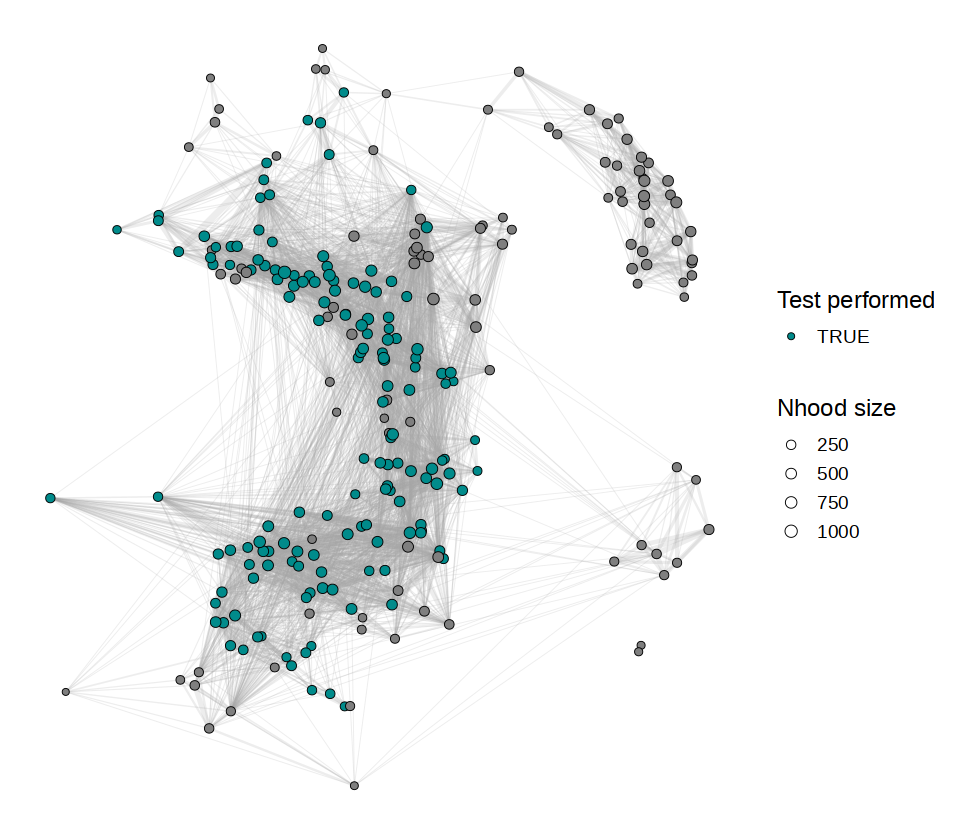

In [18]:
de_stat = de_test_neighbourhoods(sce_milo ,
                             sample_id = "sample",
                             design = ~tdTom,
                             covariates = c("tdTom"), # why covariate same as design?
                             subset_nhoods = stat_auc$Nhood[!is.na(stat_auc$auc)],
                             output_type = "SCE",
                             plot_summary_stat = TRUE,
                             layout = "umap", BPPARAM = mcparam , 
                             verbose = F)

In [19]:
head(de_stat)

class: SingleCellExperiment 
dim: 6 146 
metadata(0):
assays(4): logFC pval pval_corrected_across_genes
  pval_corrected_across_nhoods
rownames(6): Xkr4 Sox17 ... Gm37988 Tcea1
rowData names(0):
colnames(146): 2 4 ... 253 254
colData names(3): Nhood Nhood_center test_performed
reducedDimNames(0):
mainExpName: NULL
altExpNames(0):

In [88]:
saveRDS(de_stat, sprintf('%s/de_stat.rds', args$outdir))
saveRDS(sce_milo, sprintf('%s/sce_milo.rds', args$outdir))

Warning message in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_DE_genes", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.
Warning message in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_specific_DE_genes", :
“Coercing layout to matrix format”
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


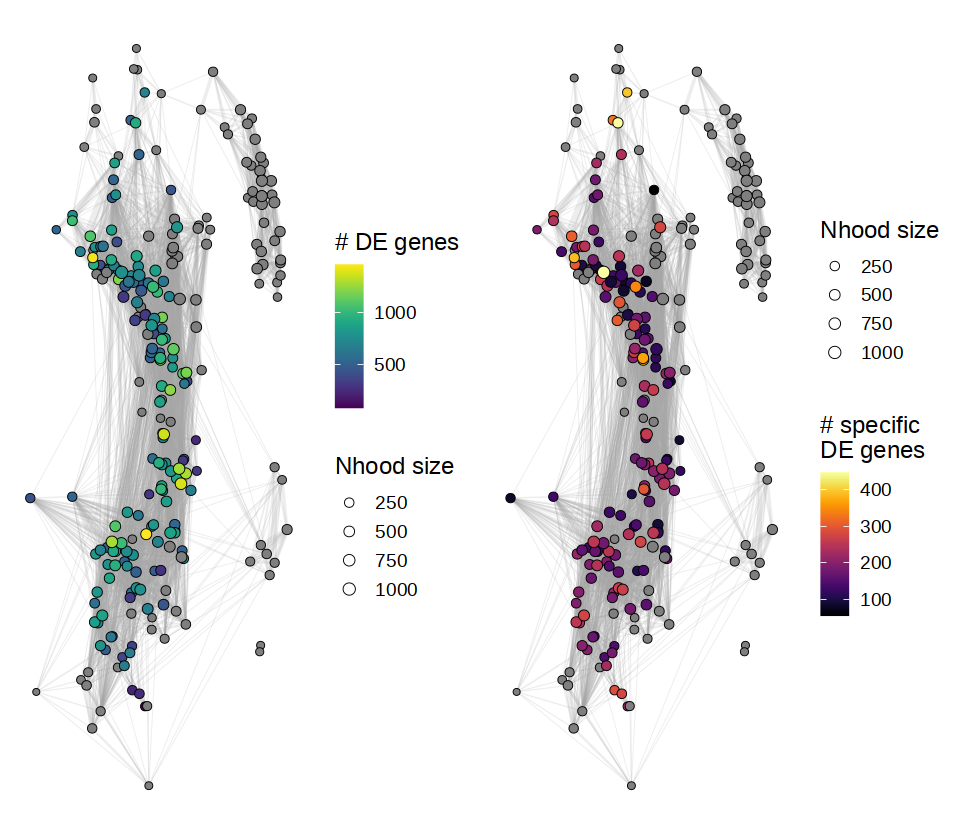

In [20]:
stat_de_magnitude = rank_neighbourhoods_by_DE_magnitude(de_stat)

p1 = plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_DE_genes" , 
                                      layout = "umap" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "# DE genes")
#> Warning in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by =
#> "n_DE_genes", : Coercing layout to matrix format
#> Scale for 'fill' is already present. Adding another scale for 'fill', which
#> will replace the existing scale.
p2 = plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by = "n_specific_DE_genes" , 
                                      layout = "umap" , size_range = c(1.5,3) , edge_width = c(0.2,0.5)) + 
  scale_fill_viridis(name = "# specific\nDE genes" , option = "inferno")
#> Warning in plot_milo_by_single_metric(sce_milo, stat_de_magnitude, colour_by =
#> "n_specific_DE_genes", : Coercing layout to matrix format
#> Scale for 'fill' is already present. Adding another scale for 'fill', which
#> will replace the existing scale.
p = ggarrange(p1,p2)
p

Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”


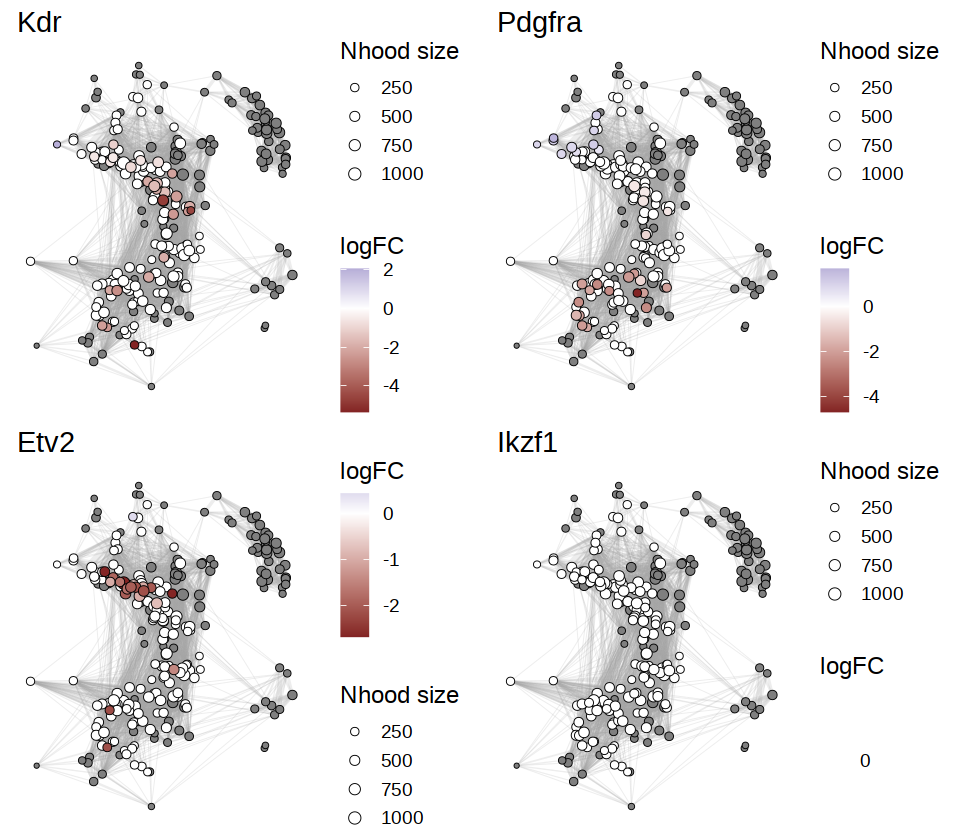

In [21]:
genes = c('Kdr','Pdgfra', 'Etv2', 'Ikzf1')
plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "umap" , set_na_to_0 = TRUE) + 
    ggtitle(gene)
  return(p)
})

p = ggarrange(plotlist = plots, ncol=2, nrow=2)
p

Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”


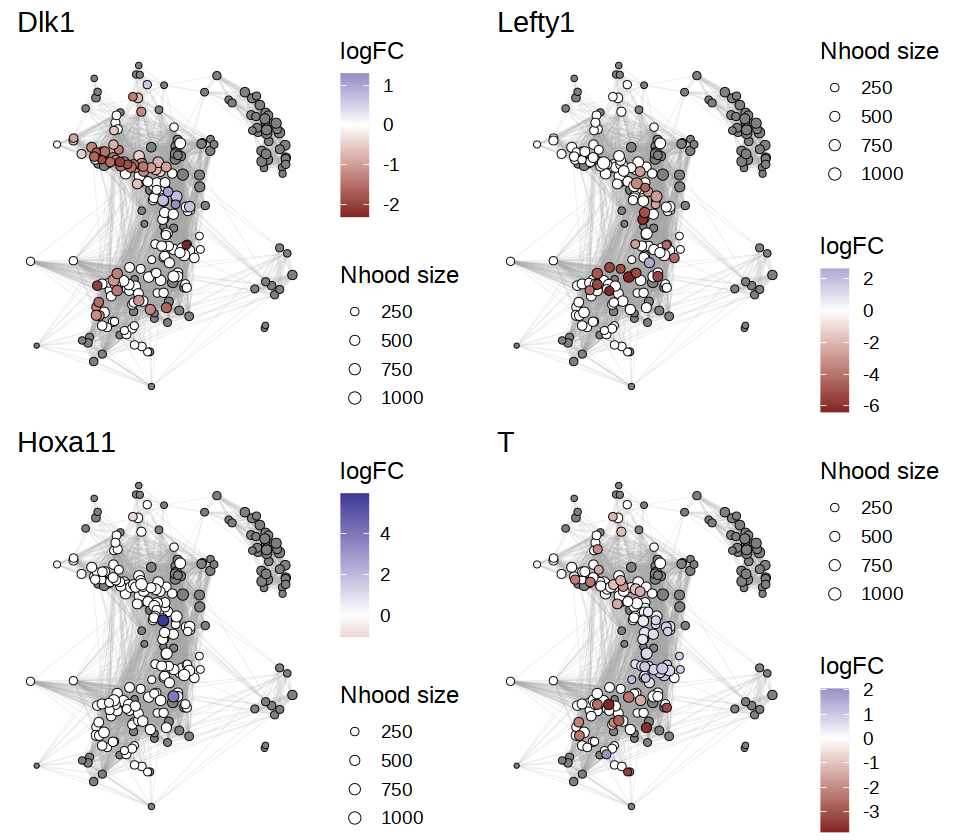

In [22]:
genes = c('Dlk1','Lefty1', 'Hoxa11', 'T')
plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "umap" , set_na_to_0 = TRUE) + 
    ggtitle(gene)
  return(p)
})

p = ggarrange(plotlist = plots, ncol=2, nrow=2)
p

In [23]:
get_wgcna_modules = function(de_stat , subset_hoods = NULL , 
                             n_hoods_sig.thresh = 2 ,
                             npcs = 5 ,
                             pval.thresh = 0.1 ){
  require(scWGCNA)
  require(Seurat)
  require(dplyr)
  require(reshape2)
  
  set.seed(32)
  # subset hoods
  if (!is.null(subset_hoods)){
    de_stat = de_stat[de_stat$Nhood %in% subset_hoods , ]
  }
  
  # focus on genes that DE in at least 2 nhoods
  de_stat_per_gene = as.data.frame(de_stat %>% group_by(gene) %>% dplyr::summarise(n_hoods_sig = sum(pval_corrected_across_nhoods < pval.thresh , na.rm = TRUE)))
  genes_sig = de_stat_per_gene$gene[de_stat_per_gene$n_hoods_sig >= n_hoods_sig.thresh]
  
  de_stat = de_stat[de_stat$gene %in% genes_sig, ]
  de_stat = de_stat[order(de_stat$Nhood) , ]
  
  # discard neighbourhoods in which testing was not performed
  de_stat = de_stat[de_stat$test_performed , ]
  
  # for this analysis, set logFC to 0 and pvals to 1 if they are NaN
  de_stat$logFC[is.na(de_stat$logFC)] = 0
  de_stat$pval[is.na(de_stat$pval)] = 1
  de_stat$pval_corrected_across_genes[is.na(de_stat$pval_corrected_across_genes)] = 1
  de_stat$pval_corrected_across_nhoods[is.na(de_stat$pval_corrected_across_nhoods)] = 1
  
  # set logFC to 0 if pval_corrected_across_nhoods > pval.thresh
  de_stat$logFC[de_stat$pval_corrected_across_nhoods >= pval.thresh] = 0
  
  # move the object to Seurat
  de_stat = reshape2::dcast(data = de_stat, formula = gene~Nhood, value.var = "logFC")
  rownames(de_stat) = de_stat$gene
  de_stat = de_stat[,2:ncol(de_stat)]
  
  obj.seurat <- CreateSeuratObject(counts = de_stat)
  DefaultAssay(obj.seurat) <- "RNA"
  obj.seurat = FindVariableFeatures(obj.seurat)
  # scale
  obj.seurat[["RNA"]]@scale.data = as.matrix(obj.seurat[["RNA"]]@data)
  obj.seurat = RunPCA(obj.seurat , npcs = npcs)
  
  # run scwgcna
  clusters_scwgcna = run.scWGCNA(p.cells = obj.seurat, 
                                 s.cells = obj.seurat, 
                                 is.pseudocell = F, 
                                 features = rownames(obj.seurat),
                                 less = TRUE , merging = TRUE)
  # compile stat
  clusters = lapply(1:length(clusters_scwgcna$module.genes) , function(i){
    out = data.frame(cluster = i , gene = clusters_scwgcna$module.genes[[i]] , n_genes = length(clusters_scwgcna$module.genes[[i]]))
    return(out)
  })
  clusters = do.call(rbind , clusters)
  # add colors
  genes_w_colors = clusters_scwgcna$dynamicCols
  genes_w_colors = data.frame(gene = names(genes_w_colors) , cluster_color = genes_w_colors)
  clusters = merge(clusters , genes_w_colors)
  
  return(clusters)
}


Warning message in eval(predvars, data, env):
“NaNs produced”
Warning message in hvf.info$variance.expected[not.const] <- 10^fit$fitted:
“number of items to replace is not a multiple of replacement length”


[1] "We have 3270 genes in the variable genes object"


Warning message:
“executing %dopar% sequentially: no parallel backend registered”
Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”
Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'y'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


   Power SFT.R.sq  slope truncated.R.sq  mean.k. median.k.  max.k.
1      1 0.000106 -0.486          0.954 1.65e+03  1.65e+03 1760.00
2      2 0.119000 -7.620          0.901 8.49e+02  8.46e+02  976.00
3      3 0.294000 -7.780          0.874 4.43e+02  4.39e+02  560.00
4      4 0.506000 -7.150          0.870 2.34e+02  2.31e+02  332.00
5      5 0.707000 -6.930          0.925 1.26e+02  1.23e+02  207.00
6      6 0.802000 -6.310          0.949 6.87e+01  6.60e+01  133.00
7      7 0.862000 -5.750          0.976 3.81e+01  3.59e+01   88.40
8      8 0.897000 -5.020          0.986 2.15e+01  1.98e+01   60.20
9      9 0.922000 -4.440          0.992 1.24e+01  1.11e+01   41.90
10    10 0.937000 -3.970          0.995 7.25e+00  6.28e+00   29.80
11    12 0.944000 -3.250          0.993 2.66e+00  2.10e+00   16.00
12    14 0.942000 -2.720          0.985 1.07e+00  7.39e-01    9.11
13    16 0.960000 -2.270          0.986 4.78e-01  2.79e-01    5.46
14    18 0.973000 -1.960          0.991 2.36e-01  1.10e-01    

Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


...

TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.
[1] "my.height:  0.995  .... my.Clsize:  17"
 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 22 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 17 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 16 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 15 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 15 module eigengenes in given s

Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.
[1] "my.height:  0.9945  .... my.Clsize:  17"
 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 22 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 17 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 16 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 15 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 15 module eigengenes in given 

Warning message in (function (x, y = NULL, robustX = TRUE, robustY = TRUE, use = "all.obs", :
“bicor: zero MAD in variable 'x'. Pearson correlation was used for individual columns with zero (or missing) MAD.”


TOM calculation: adjacency..
..will not use multithreading.
 Fraction of slow calculations: 0.000000
..connectivity..
..matrix multiplication (system BLAS)..
..normalization..
..done.
[1] "my.height:  0.9945  .... my.Clsize:  17"
 mergeCloseModules: Merging modules whose distance is less than 0.25
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 22 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 17 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 16 module eigengenes in given set.
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 15 module eigengenes in given set.
   Calculating new MEs...
   multiSetMEs: Calculating module MEs.
     Working on set 1 ...
     moduleEigengenes: Calculating 15 module eigengenes in given 

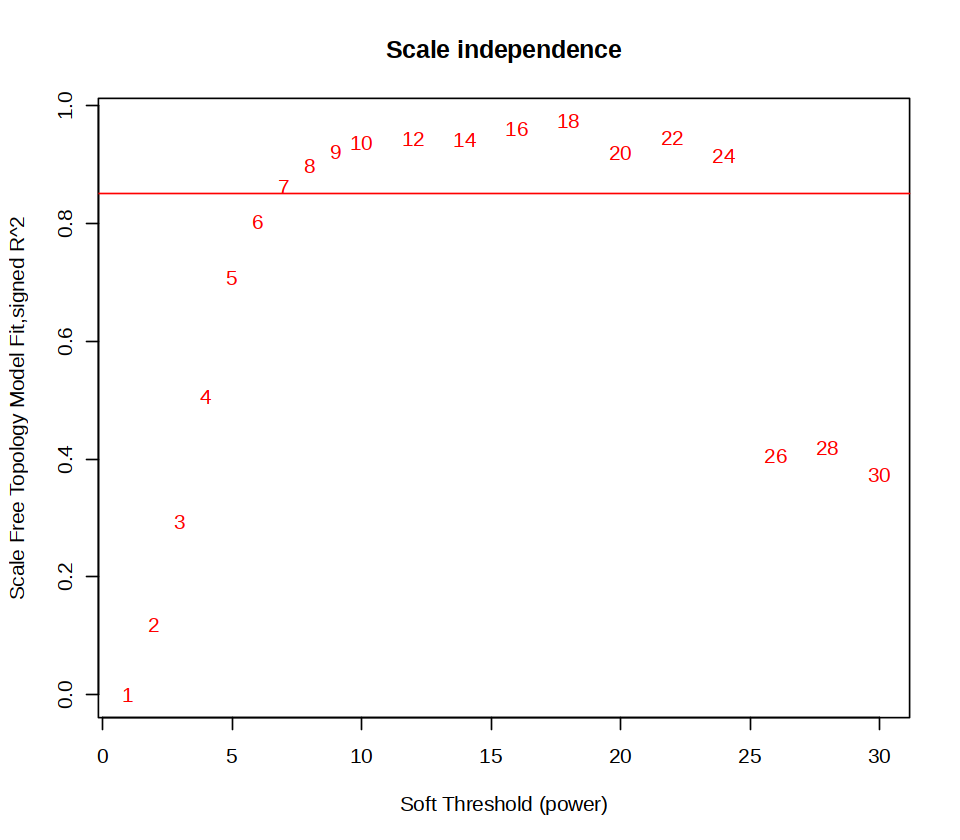

In [24]:
# for this vignette, for simplicity we will focus on genes that are DE in at least 4 neighbourhoods
modules_wgcna = suppressMessages(get_wgcna_modules(convert_de_stat(de_stat) , n_hoods_sig.thresh = 4))

In [89]:
fwrite(modules_wgcna, sprintf('%s/modules_wgcna.txt.gz', args$outdir))

In [25]:
plots = lapply(sort(unique(modules_wgcna$cluster)) , function(cluster){
  p = plot_DE_gene_set(sce_milo, de_stat , genes = modules_wgcna$gene[modules_wgcna$cluster == cluster],
                            layout = "umap" , size_range = c(0.5,3) ,
                            node_stroke = 0.3, edge_width = c(0.2,0.5)) +
    ggtitle(paste0("Module ", cluster, ", ", length(modules_wgcna$gene[modules_wgcna$cluster == cluster]) , " genes"))
  return(p)
})

Warning message in plot_milo_by_single_metric(x, nhood_stat, colour_by = "avg_logFC", :
“Coercing layout to matrix format”
Warning message in plot_milo_by_single_metric(x, nhood_stat, colour_by = "avg_logFC", :
“Coercing layout to matrix format”
Warning message in plot_milo_by_single_metric(x, nhood_stat, colour_by = "avg_logFC", :
“Coercing layout to matrix format”
Warning message in plot_milo_by_single_metric(x, nhood_stat, colour_by = "avg_logFC", :
“Coercing layout to matrix format”
Warning message in plot_milo_by_single_metric(x, nhood_stat, colour_by = "avg_logFC", :
“Coercing layout to matrix format”
Warning message in plot_milo_by_single_metric(x, nhood_stat, colour_by = "avg_logFC", :
“Coercing layout to matrix format”
Warning message in plot_milo_by_single_metric(x, nhood_stat, colour_by = "avg_logFC", :
“Coercing layout to matrix format”
Warning message in plot_milo_by_single_metric(x, nhood_stat, colour_by = "avg_logFC", :
“Coercing layout to matrix format”
Warning message 

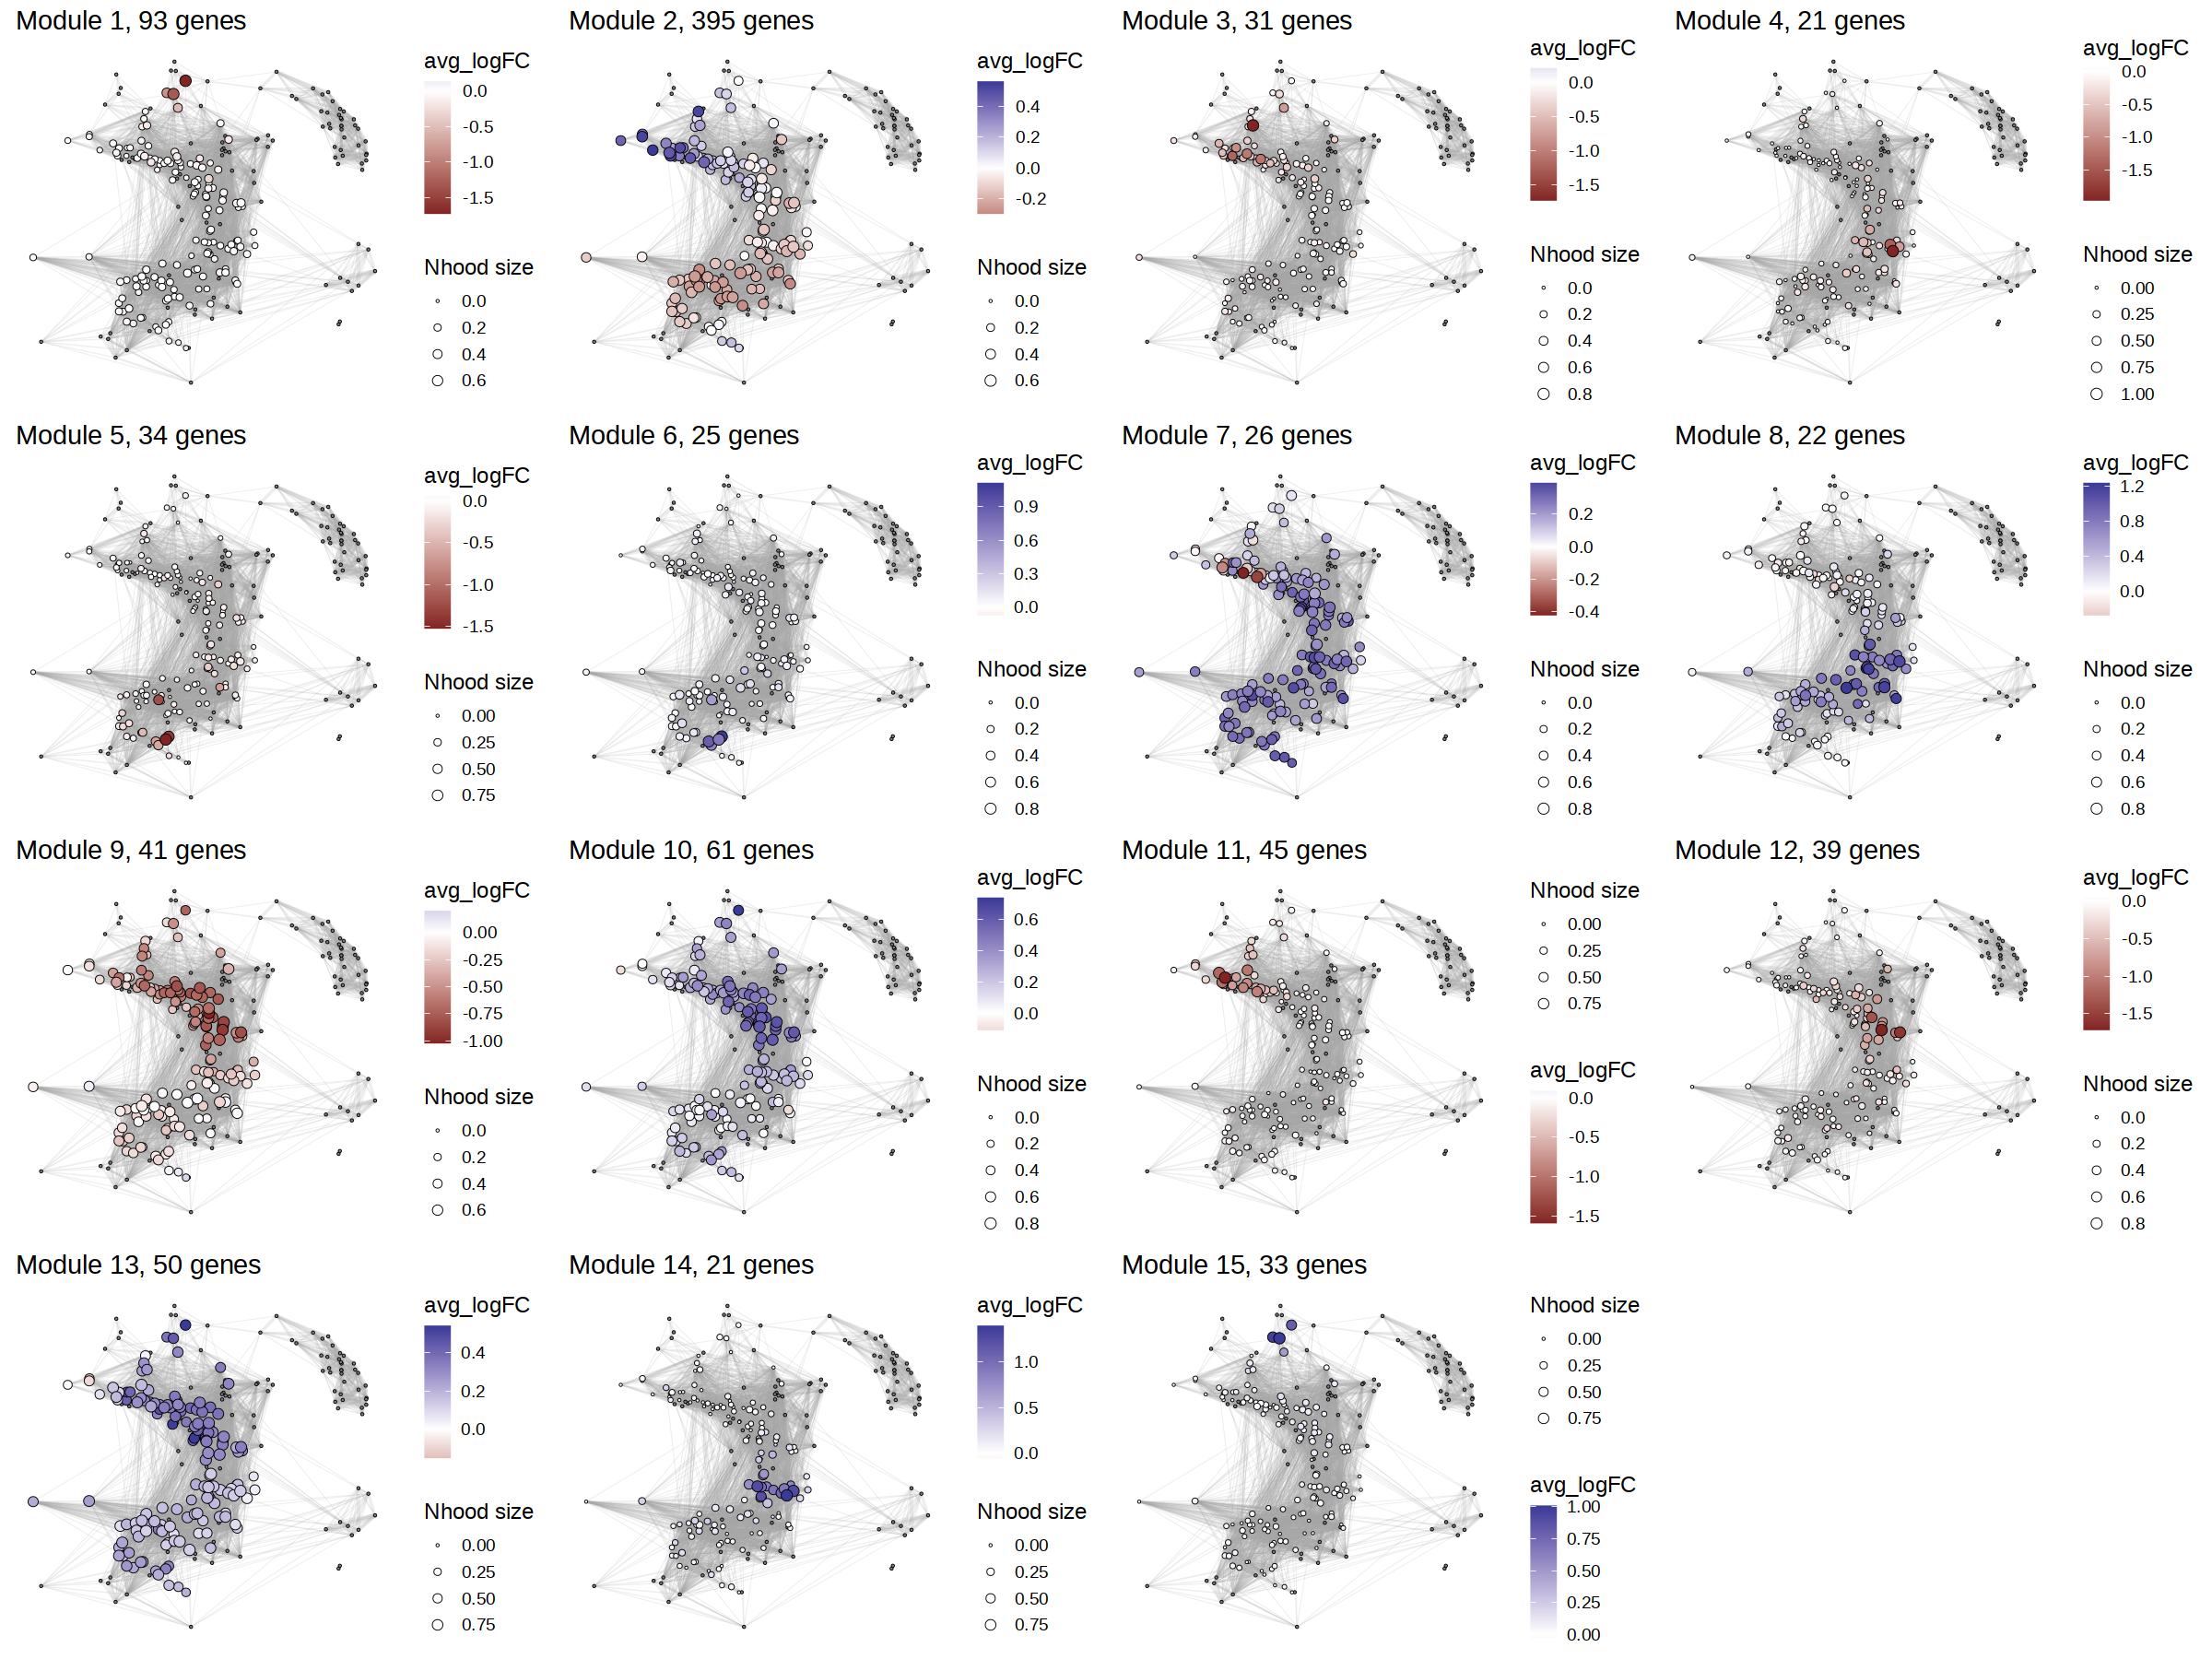

In [26]:
options(repr.plot.height=15, repr.plot.width=20)
p = ggarrange(plotlist = plots)
p

Converting de_stat to 'data.frame' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format

Converting de_stat to 'SingleCellExperiment' format



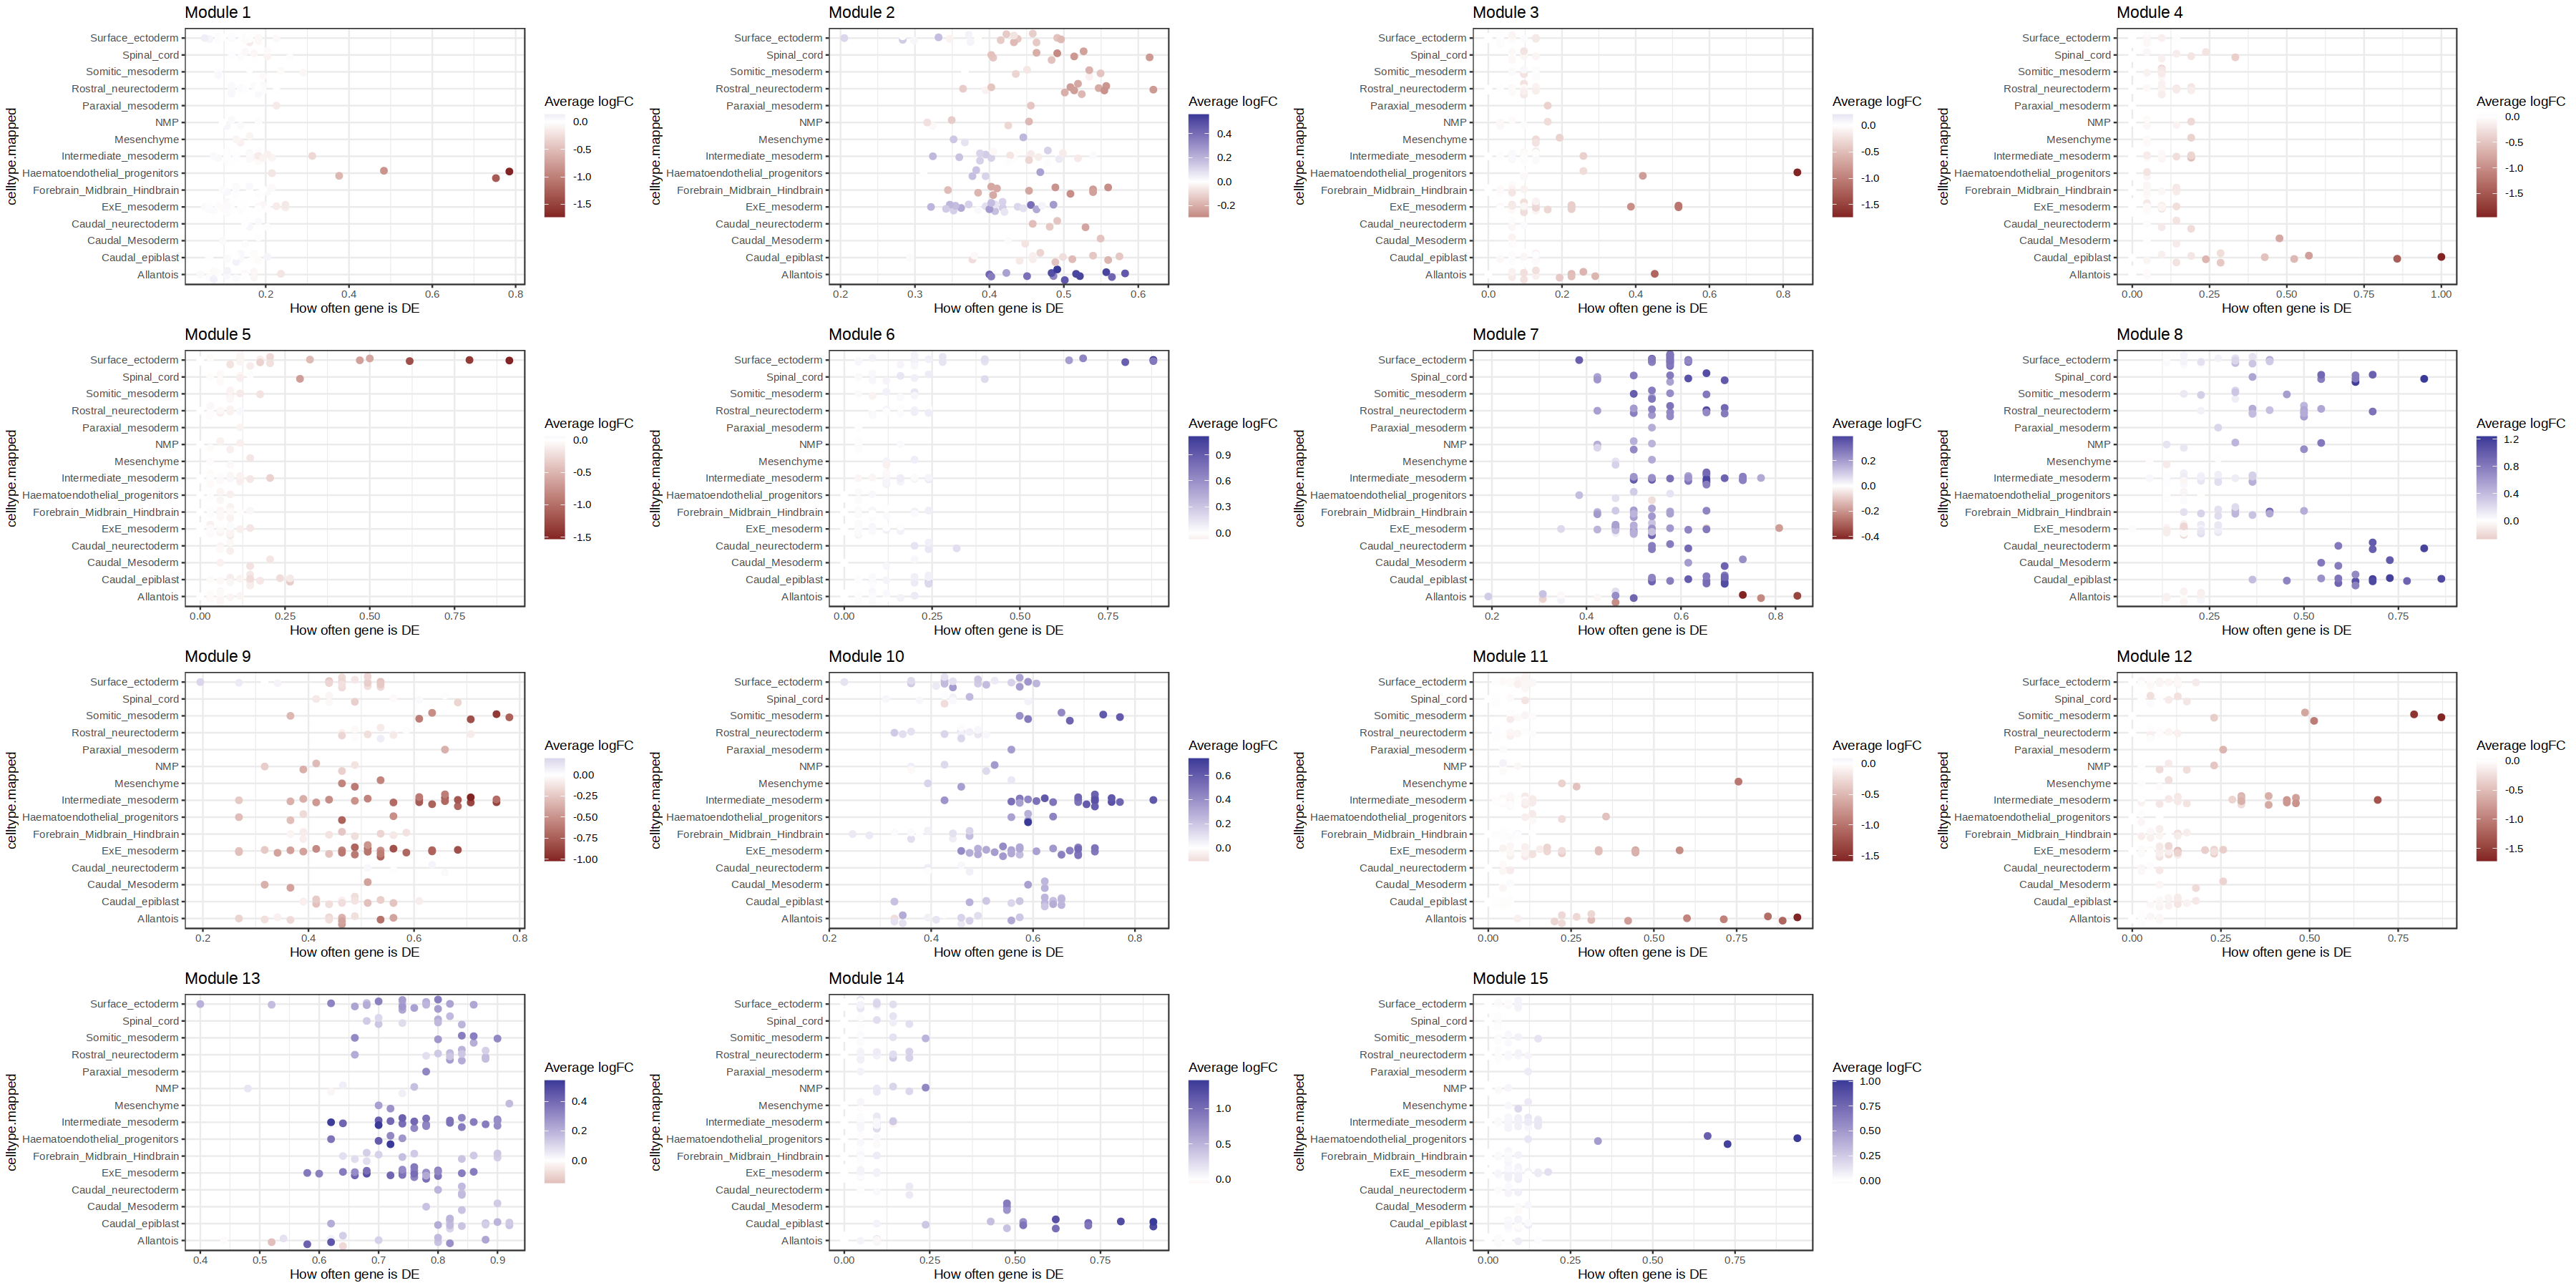

In [27]:
# we first need to assign cell type label to each neighbourhood - we have calculated it previously
# we will use data.frame format for de-stat; the conversion between SingleCellExperiment and data.frame formats can be done using `convert_de_stat`
de_stat_df = convert_de_stat(de_stat)
#> Converting de_stat to 'data.frame' format
de_stat_df = merge(de_stat_df , nhood_stat_ct , by = c("Nhood" , "Nhood_center"))


plots = lapply(sort(unique(modules_wgcna$cluster)) , function(cluster){
  p = plot_beeswarm_gene_set(de_stat_df, 
                             genes = modules_wgcna$gene[modules_wgcna$cluster == cluster], 
                             nhoodGroup = "celltype.mapped") + 
    ggtitle(paste0("Module ", cluster))
  return(p)
})
p = ggarrange(plotlist = plots)
options(repr.plot.height=15, repr.plot.width=30)
p

In [92]:
modules_wgcna[modules_wgcna$cluster == 19,]$gene

[1] "2700038G22Rik" "Adam10"        "Cfl2"          "Cracd"        
 [5] "E2f5"          "Fn1"           "Gjc1"          "Gm4425"       
 [9] "Gpc3"          "Gsc"           "Micos13"       "N4bp2"        
[13] "Olfml3"        "Pak2"          "Ppp3ca"        "Romo1"        
[17] "Sf3a2"         "Slc3a2"        "Srgap3"        "Stub1"        
[21] "Trir"          "Ube3a"         "Usp34"         "Utrn"

Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”


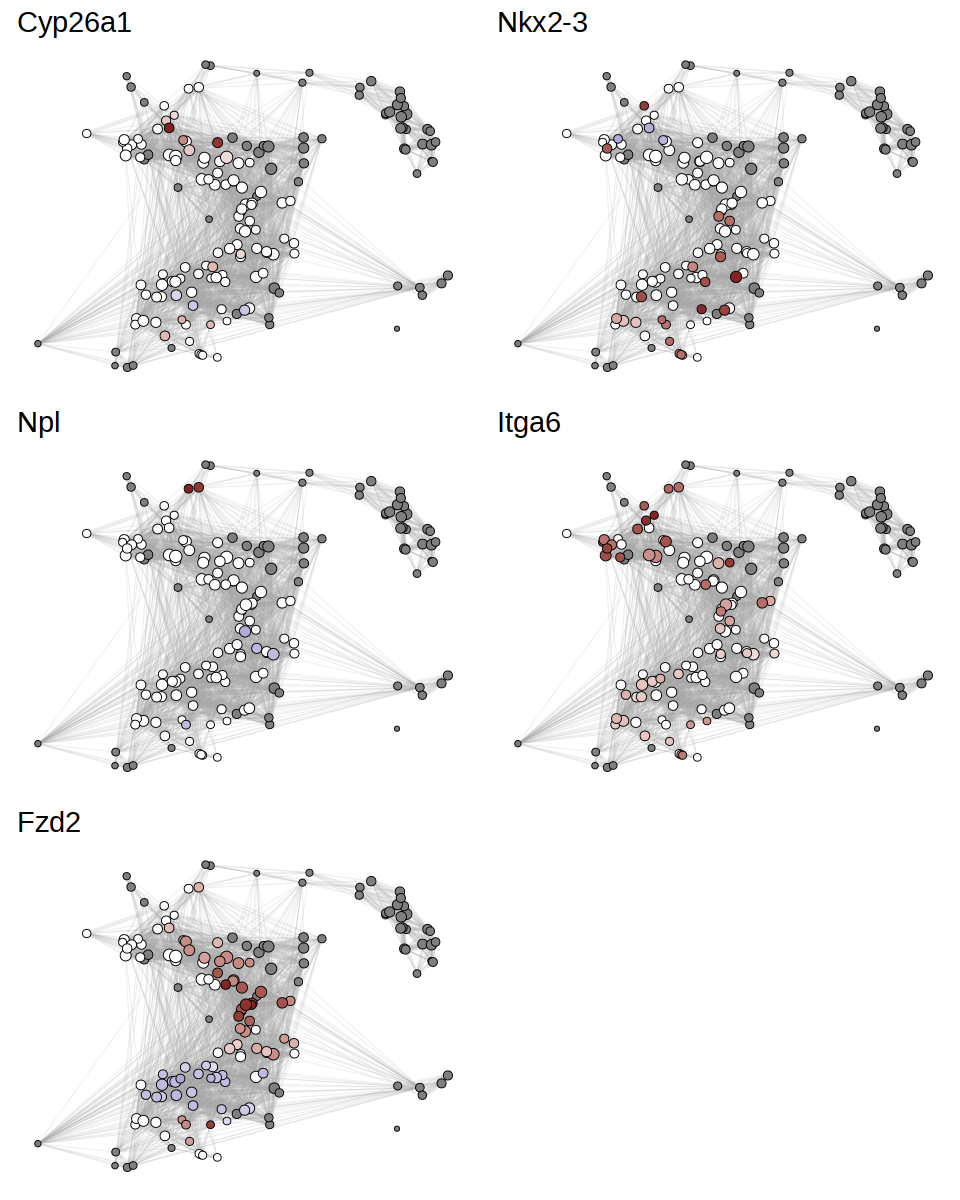

In [45]:
genes = c('Cyp26a1', 'Nkx2-3', 'Npl', 'Itga6', 'Fzd2')

plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "umap" , set_na_to_0 = TRUE) + 
    ggtitle(gene) + theme(legend.position='none')
  return(p)
})
options(repr.plot.height=10, repr.plot.width=8)
p = ggarrange(plotlist = plots , ncol = 2, nrow = 3) 
p

Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”


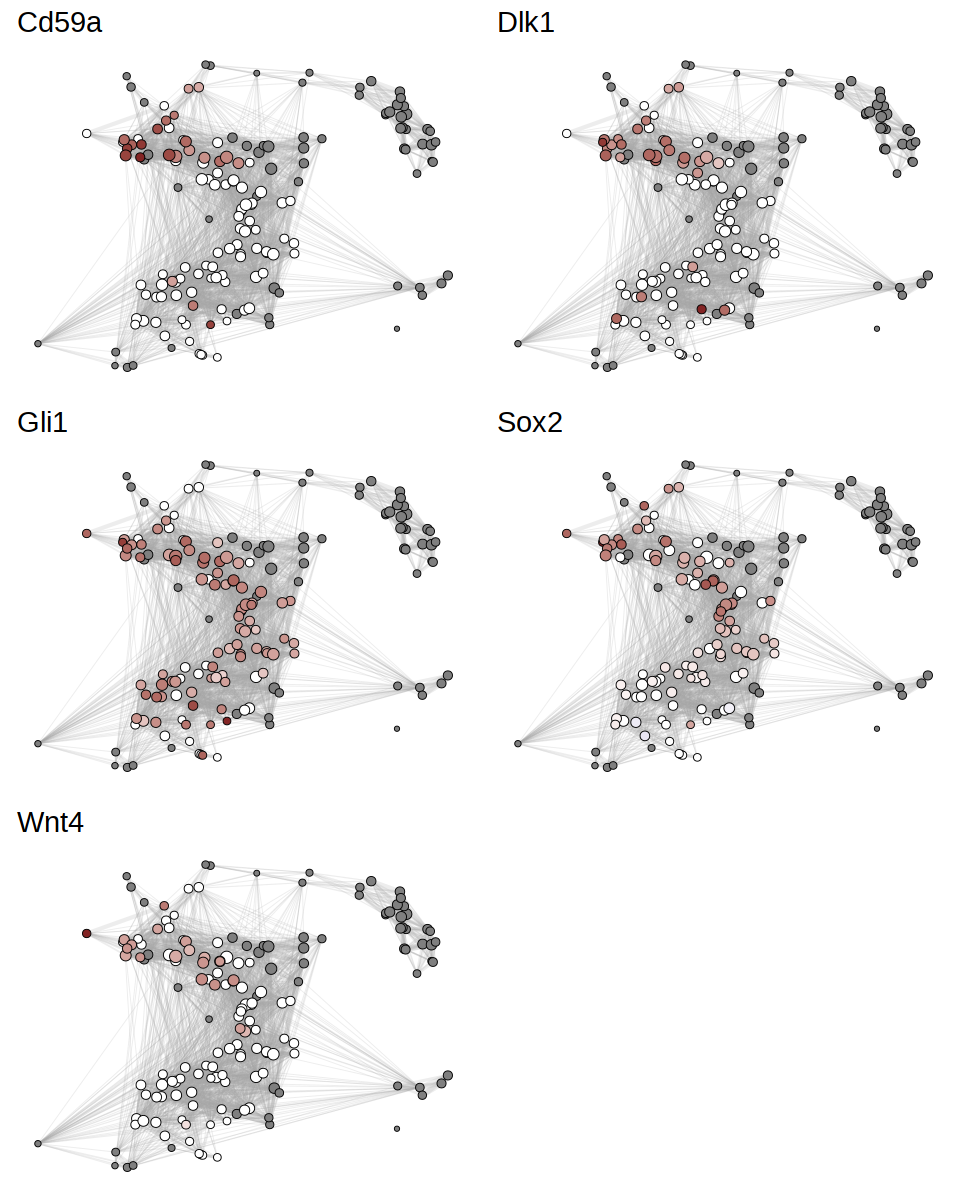

In [41]:
genes = c('Cd59a', 'Dlk1', 'Gli1', 'Sox2', 'Wnt4')

plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "umap" , set_na_to_0 = TRUE) + 
    ggtitle(gene) + theme(legend.position='none')
  return(p)
})
options(repr.plot.height=10, repr.plot.width=8)
p = ggarrange(plotlist = plots , ncol = 2, nrow = 3) 
p

In [28]:
modules_wgcna[modules_wgcna$cluster == 9,]$gene

[1] "Anp32a"   "Atp5l"    "Ccdc80"   "Cd24a"    "Cdx1"     "Cited2"  
 [7] "Ddias"    "Ddx39a"   "Dusp9"    "Efnb1"    "Fzd2"     "H2bu2"   
[13] "Hba-a2"   "Igfbp2"   "Iqgap2"   "Irx1"     "Mdh1"     "Meg3"    
[19] "Mt1"      "Myl2"     "Nectin2"  "Nnat"     "Nr6a1"    "Pkdcc"   
[25] "Prkar1a"  "Psmb3"    "Ptn"      "Rbp1"     "Resf1"    "Rest"    
[31] "Rpl22l1"  "Rras"     "S100a6"   "Slc2a1"   "Snrpn"    "Stard3nl"
[37] "Tcf7l2"   "Tmsb4x"   "Tubb4a"   "Upp1"     "Usp22"

In [ ]:
genes = modules_wgcna[modules_wgcna$cluster == 9,]$gene

plots = mclapply(genes , function(gene){
  p = suppressWarnings(plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "umap" , set_na_to_0 = TRUE)) + 
    ggtitle(gene) + theme(legend.position='none')
  return(p)
}, mc.cores=12)
options(repr.plot.height=8, repr.plot.width=25)
p = ggarrange(plotlist = plots , ncol = 7) 
p

In [44]:
modules_wgcna[modules_wgcna$cluster == 3,]$gene

[1] "2400006E01Rik" "Acer2"         "Aen"           "Afdn"         
 [5] "Ak1"           "Akr1b8"        "Apoe"          "Bax"          
 [9] "Bmerb1"        "Bst2"          "Btg2"          "Calm1"        
[13] "Canx"          "Capsl"         "Car2"          "Cdx1"         
[17] "Col18a1"       "Cox6b2"        "Cstb"          "Cyfip2"       
[21] "Ddt"           "Ddx39a"        "Dst"           "Efcab15"      
[25] "Epcam"         "Epp13"         "Esco2"         "Fmr1nb"       
[29] "Fscn1"         "Fst"           "Gap43"         "Gata5"        
[33] "Gbx2"          "Gdpd1"         "Gm11627"       "Gm43803"      
[37] "Gngt2"         "Grb7"          "H2-D1"         "H2bu2"        
[41] "Hacd2"         "Hsp90b1"       "Hspa5"         "Itga4"        
[45] "Lcmt1"         "Map3k20"       "Meg3"          "Mis12"        
[49] "Mlec"          "Mpv17"         "Myl12b"        "Naip5"        
[53] "Ndufb6"        "Nectin2"       "Nfe2l1"        "Pcsk1n"       
[57] "Pdcd6"         "Pdgfa"         "Pdia4"         "Perp"         
[61] "Plaat3"        "Popdc2"        "Pou5f1"        "Ppib"         
[65] "Ptpn18"        "Rab25"         "Rab3il1"       "Rbms1"        
[69] "Rbpms2"        "Rhod"          "Rps27l"        "Rras"         
[73] "Sec63"         "Selenom"       "Sesn2"         "Sirt7"        
[77] "Slc35b1"       "Snrpn"         "Sptbn1"        "Srp9"         
[81] "St14"          "Tbca"          "Tec"           "Ten1"         
[85] "Tmsb4x"        "Trp53"         "Tsen54"        "Uaca"         
[89] "Upp1"          "Vmp1"          "Vps29"         "Wfdc2"        
[93] "Zdhhc12"       "Zfp365"

Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”


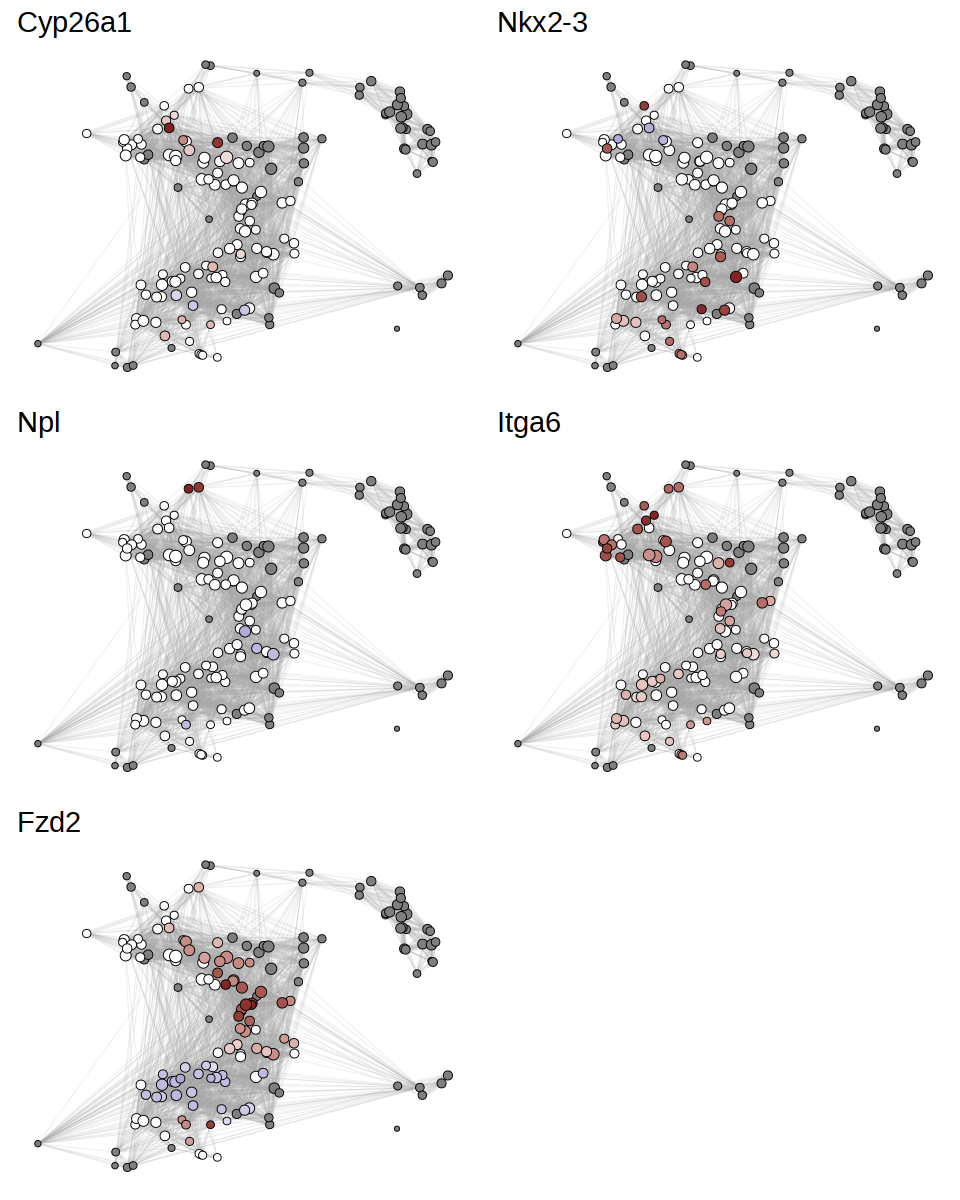

In [45]:
genes = c('Cyp26a1', 'Nkx2-3', 'Npl', 'Itga6', 'Fzd2')

plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "umap" , set_na_to_0 = TRUE) + 
    ggtitle(gene) + theme(legend.position='none')
  return(p)
})
options(repr.plot.height=10, repr.plot.width=8)
p = ggarrange(plotlist = plots , ncol = 2, nrow = 3) 
p

Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”
Converting de_stat to 'data.frame' format

Warning message in plot_milo_by_single_metric(x, nhood_stat = nhood_stat, colour_by = "logFC", :
“Coercing layout to matrix format”


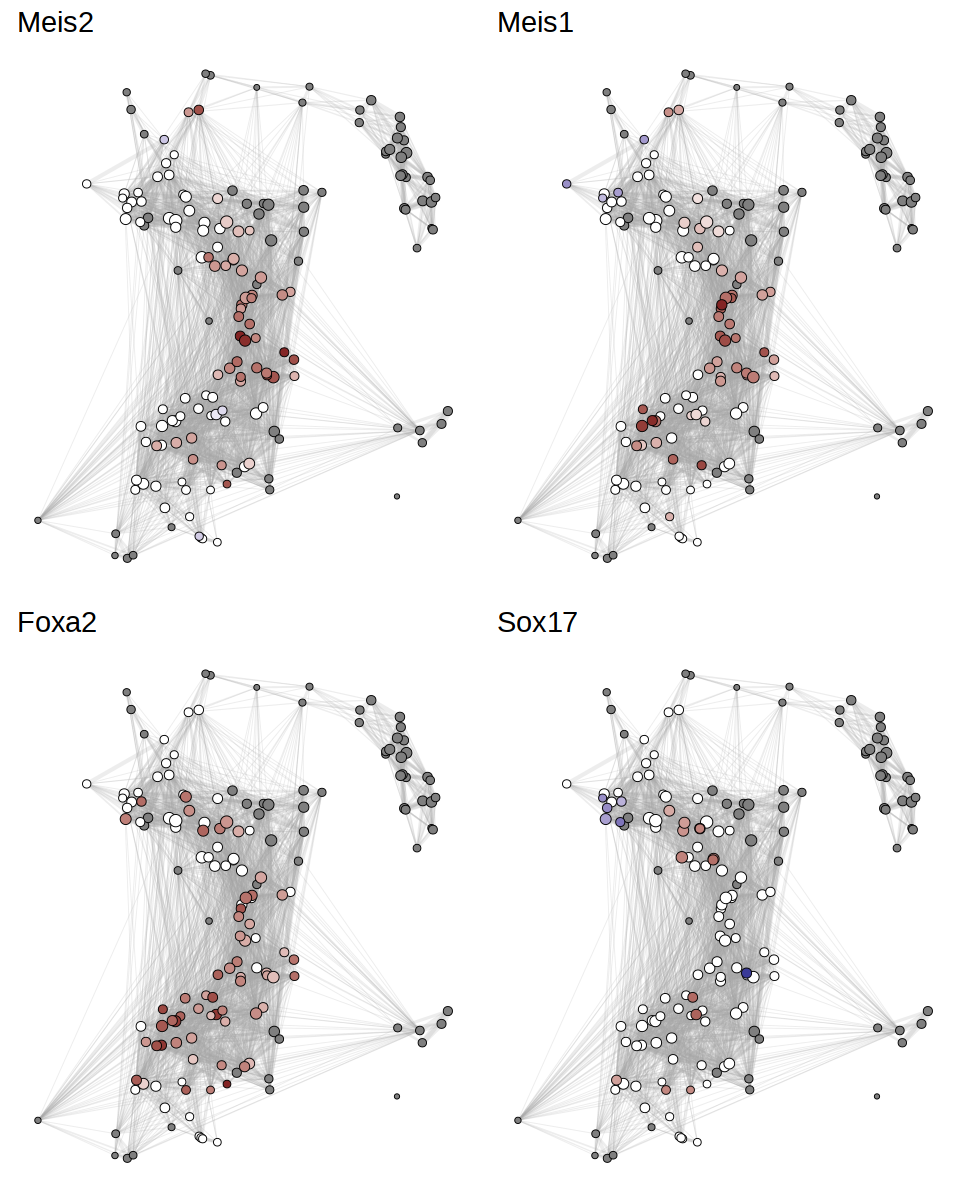

In [46]:
genes = c('Meis2', 'Meis1', 'Foxa2', 'Sox17')

plots = lapply(genes , function(gene){
  p = plot_DE_single_gene(sce_milo, de_stat , gene = gene , layout = "umap" , set_na_to_0 = TRUE) + 
    ggtitle(gene) + theme(legend.position='none')
  return(p)
})
options(repr.plot.height=10, repr.plot.width=8)
p = ggarrange(plotlist = plots , ncol = 2, nrow = 2) 
p

In [47]:
modules_wgcna[modules_wgcna$cluster == 8,]$gene

modules_wgcna[modules_wgcna$cluster == 12,]$gene

[1] "Cpxm1"    "Creb3l2"  "Dcn"      "Fstl1"    "Fzd10"    "Glud1"   
 [7] "H19"      "Hook3"    "Hotairm1" "Kit"      "Krt19"    "Lifr"    
[13] "Msx1"     "Pdxdc1"   "Pdzrn3"   "Pon2"     "Pou6f2"   "Rad21"   
[19] "Rsrc1"    "Scarb1"   "Selenop"  "Sema3e"   "Sh3rf1"   "Slit2"   
[25] "Tor1aip1" "Zfp639"

[1] "Cdx4"     "Crb2"     "Dynll2"   "Eif5b"    "Gm53"     "Hoxa7"   
 [7] "Hoxb6"    "Hoxb7"    "Hoxb8"    "Hoxb9"    "Hoxd10"   "Mocs2"   
[13] "Mtap"     "Poldip2"  "Psmb10"   "Purb"     "Rab5c"    "Rnf213"  
[19] "Slc25a13" "Snhg20"   "Tk1"      "Tmem97"   "Trim71"   "Tubg1"   
[25] "Uhrf1"    "Wnt5a"    "Xlr4a"    "Zfp800"   "Zfyve9"

In [48]:
### Export modules for metascape

# Get gene lists
gene_lists = lapply(unique(modules_wgcna$cluster), function(x){
    genes = modules_wgcna[modules_wgcna$cluster == x]$gene
})

# Get max length 
max = max(length(gene_lists))
x = c(x, rep(NA, max.len - length(x)))



ERROR: Error in `[.data.frame`(modules_wgcna, modules_wgcna$cluster == x): undefined columns selected


In [64]:
# Get gene lists
gene_lists = lapply(unique(modules_wgcna$cluster), function(x){
    genes = as.data.table(modules_wgcna)[cluster == x]$gene
    return(genes)
})

In [74]:
max_length = max(sapply(gene_lists, length))

In [81]:
# Get gene lists
DEGs.dt = lapply(unique(modules_wgcna$cluster), function(x){
    genes = as.data.table(modules_wgcna)[cluster == x]$gene
    tmp = data.table('x' = c(genes, rep(NA, max_length - length(genes)))) %>% setnames(paste0('Module_',x))
    return(tmp)
}) %>% do.call('cbind', .)

In [85]:
fwrite(DEGs.dt, sprintf('%s/module_genes.csv', args$outdir))